In [358]:
# import required library 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [271]:
# create a connection 
conn = psycopg2.connect(
    host="localhost",
    database="internproject",   
    user="postgres",       
    password="Yusufrazakhan12@", 
    port="5432"
)

### Load Data Set

In [272]:
tables = pd.read_sql_query(
    "SELECT table_name FROM information_schema.tables WHERE table_schema = 'public'",
    conn)
tables

,table_name
0,supermart_grocery_sales
1,tcs_cleaned_data
2,googleplaystore
3,netflix1
4,netflix_clean
5,tcs_stock_history


In [273]:
# Now Fetch Data From DataBase
data = pd.read_sql('Select * from "googleplaystore"',conn)
data.head(5)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### Understand the data 

In [274]:
# data head
data.head(3)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [275]:
# data tail
data.tail(3)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [276]:
# data shape
data.shape

(10841, 13)

In [277]:
# data info (datatype , missing values)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app             10841 non-null  object 
 1   category        10841 non-null  object 
 2   rating          9367 non-null   float64
 3   reviews         10841 non-null  object 
 4   size            10841 non-null  object 
 5   installs        10841 non-null  object 
 6   type            10840 non-null  object 
 7   price           10841 non-null  object 
 8   content_rating  10840 non-null  object 
 9   genres          10841 non-null  object 
 10  last_updated    10841 non-null  object 
 11  current_ver     10833 non-null  object 
 12  android_ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


###  1 Data Cleaning and Preprocessing

In [278]:
# check Null Values
data.isnull().sum()

app                  0
category             0
rating            1474
reviews              0
size                 0
installs             0
type                 1
price                0
content_rating       1
genres               0
last_updated         0
current_ver          8
android_ver          3
dtype: int64

In [279]:
# check null values in terms of percentages
data.isnull().sum()/data.shape[0]*100

app                0.000000
category           0.000000
rating            13.596532
reviews            0.000000
size               0.000000
installs           0.000000
type               0.009224
price              0.000000
content_rating     0.009224
genres             0.000000
last_updated       0.000000
current_ver        0.073794
android_ver        0.027673
dtype: float64

``` So here the null values is very less so inted of removing we apply some method and fill the values ```

In [280]:
# Handel missing values 
data['rating'].fillna(data['rating'].median(),inplace = True)

data['type'].fillna(data['type'].mode()[0],inplace = True)

data['content_rating'].fillna(data['content_rating'].mode()[0],inplace = True)

data['current_ver'].fillna("Unknown", inplace=True)
data['android_ver'].fillna("Unknown", inplace=True)

In [281]:
# Check data
data.isnull().sum()

app               0
category          0
rating            0
reviews           0
size              0
installs          0
type              0
price             0
content_rating    0
genres            0
last_updated      0
current_ver       0
android_ver       0
dtype: int64

#### 2. Converting Columns to Appropriate Data Types:
##### Convert Reviews and Installs to integer types.
##### Convert Price to numeric.
##### Convert Size to a uniform numeric format.

In [282]:
# check data columns
data.columns

Index(['app', 'category', 'rating', 'reviews', 'size', 'installs', 'type',
       'price', 'content_rating', 'genres', 'last_updated', 'current_ver',
       'android_ver'],
      dtype='object')

``` 2.1 Convert Reviews and Installs to integer types```

``` Reviews```

In [283]:
data['reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'],
      shape=(6002,), dtype=object)

In [284]:
data[data['reviews'] == '3.0M']

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,Everyone,"February 11, 2018",1.0.19,4.0 and up,Unknown


In [285]:
data.drop(index=10472, inplace=True)

In [286]:
# Convert 'Reviews' to integer
data['reviews'] = data['reviews'].astype(int)

In [287]:
data['reviews'].dtypes

dtype('int64')

```Size```

In [288]:
data['size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '3.9M', '8.0M', '7.9M', '56M', '57M', '35M', '54M',
       '201k', '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M',
       '3.4M', '8.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [289]:
# Convert 'Size' to numeric (MB) - Convert 'k' to MB
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1000
    else:
        return np.nan
        
data['size'] = data['size'].apply(convert_size)

```Install```

In [290]:
# check unique value in the perticular column 
data['installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100+',
       '100,000,000+', '1,000,000,000+', '1,000+', '500,000,000+', '50+',
       '500+', '10+', '1+', '5+', '0+', '0'], dtype=object)

In [291]:
# Convert 'Installs' by removing '+' and ',' then converting to integer
data['installs'] = data['installs'].apply(lambda x: x.replace(',','').replace('+', '')).astype(float)

``` Price```

In [292]:
data['price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [293]:
# Convert 'Price' by removing '$' and converting to float
data['price'] = data['price'].apply(lambda x: float(x.replace('$', ''))if '$' in x else float(x))

#### 3 Handelling Duplicate

In [294]:
# Check for duplicates
data.duplicated().sum()

np.int64(483)

In [295]:
# Remove duplicates
data.drop_duplicates(inplace=True)

#### 4: Exploratory Data Analysis (EDA)

In [296]:
# statical summary 
data.describe()

,rating,reviews,size,installs,price
count,10357.000000,1.035700e+04,8831.000000,1.035700e+04,10357.000000
mean,4.203737,4.059046e+05,21.287788,1.415776e+07,1.030800
std,0.485594,2.696778e+06,22.540247,8.023955e+07,16.278625
min,1.000000,0.000000e+00,0.008500,0.000000e+00,0.000000
25%,4.100000,3.200000e+01,4.700000,1.000000e+03,0.000000
50%,4.300000,1.680000e+03,13.000000,1.000000e+05,0.000000
75%,4.500000,4.641600e+04,29.000000,1.000000e+06,0.000000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000


In [297]:
# Numerical columns 
numeric_cols = data.select_dtypes(include=['int64','float64']).columns

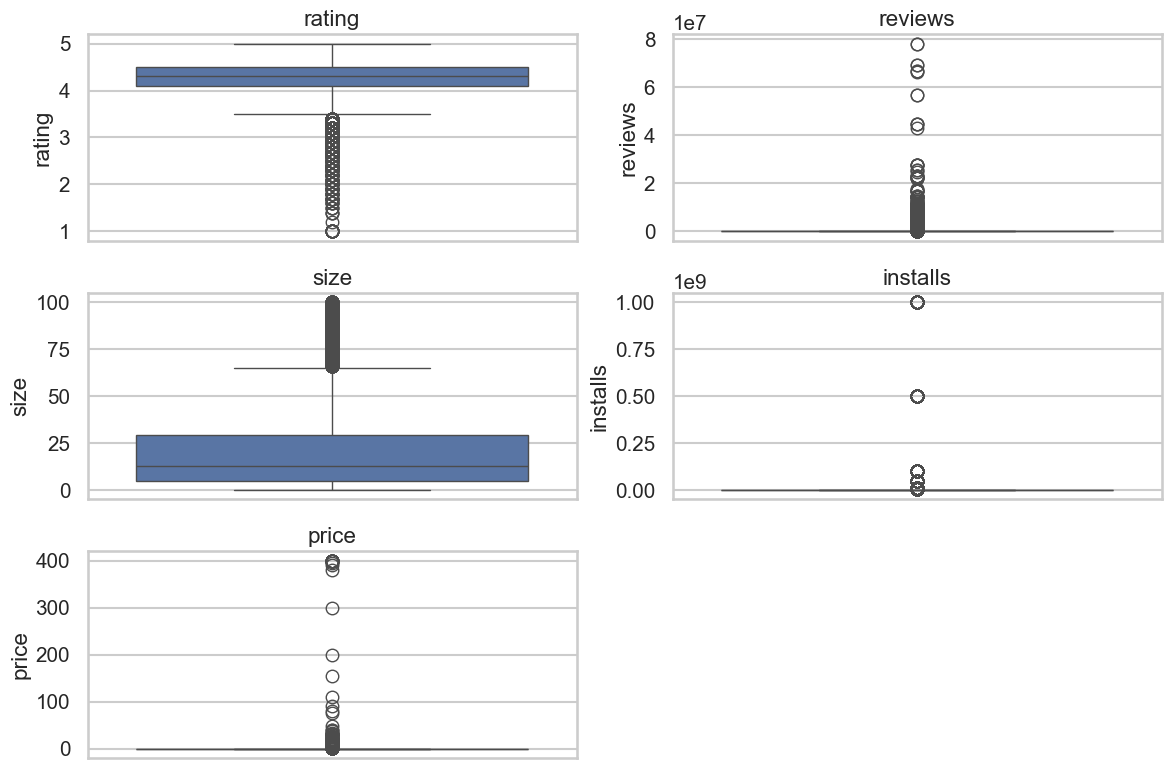

In [298]:
# Outlier Detection with boxplot
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 2, i+1) 
    sns.boxplot(y=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()


#### Statical insights

###### ```Ratings:``` Most apps have high ratings, which shows that users are generally satisfied with the applications on the Play Store.

###### ```Reviews:``` A large number of apps have very few reviews, while only a small number of popular apps receive a very high number of reviews.

###### ```Install:``` Install counts are not evenly distributed; most apps have low installs, and only a few apps achieve very high download numbers.

###### ``` Apps:``` App sizes vary a lot, ranging from small lightweight apps to large apps, depending on their functionality and purpose.

###### ```Price:``` The majority of apps are free, and only a small number of apps are paid and expensive.

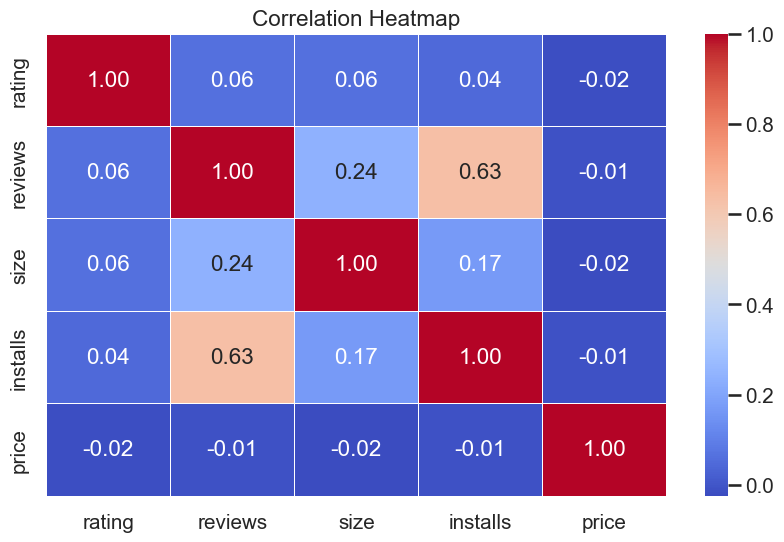

In [299]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
correlation_matrix = data[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

#### Heatmap Insights

``` Reviews and installs:``` have a strong positive relationship, showing that apps with more reviews usually have more downloads.

```App:``` size has a weak positive relationship with reviews and installs, indicating limited impact on popularity.

```Ratings:```  show very weak correlation with other variables, meaning high installs do not guarantee high ratings.

```Price:```  has almost no correlation with ratings, installs, or reviews, highlighting the dominance of free apps.

```4.1 Distribution of App Ratings```

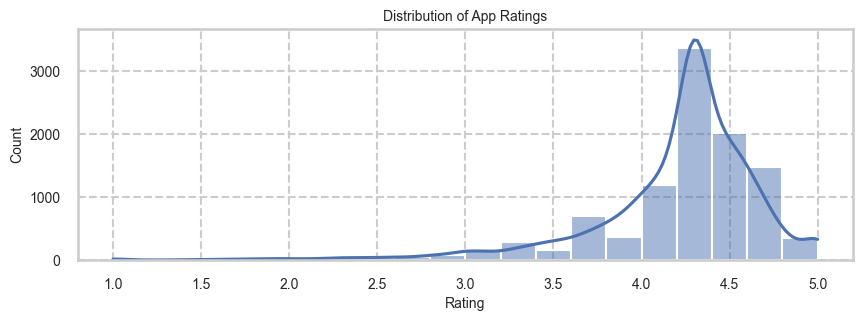

In [300]:
# plot the graph 
plt.figure(figsize=(10,3))
sns.histplot(data['rating'].dropna(), bins=20,kde=True, palette='Set2')

plt.grid(linestyle = "--")
# label and title 
plt.title('Distribution of App Ratings',fontsize = 10)
plt.xlabel('Rating',fontsize = 10)
plt.xticks(fontsize = 10)
plt.ylabel('Count',fontsize = 10)
plt.yticks(fontsize = 10)
plt.show()

```4.2: Top 10 Categories by Number of Apps```

In [301]:
# find top categories
top_categories = data['category'].value_counts()
top_categories.head(10)

category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64

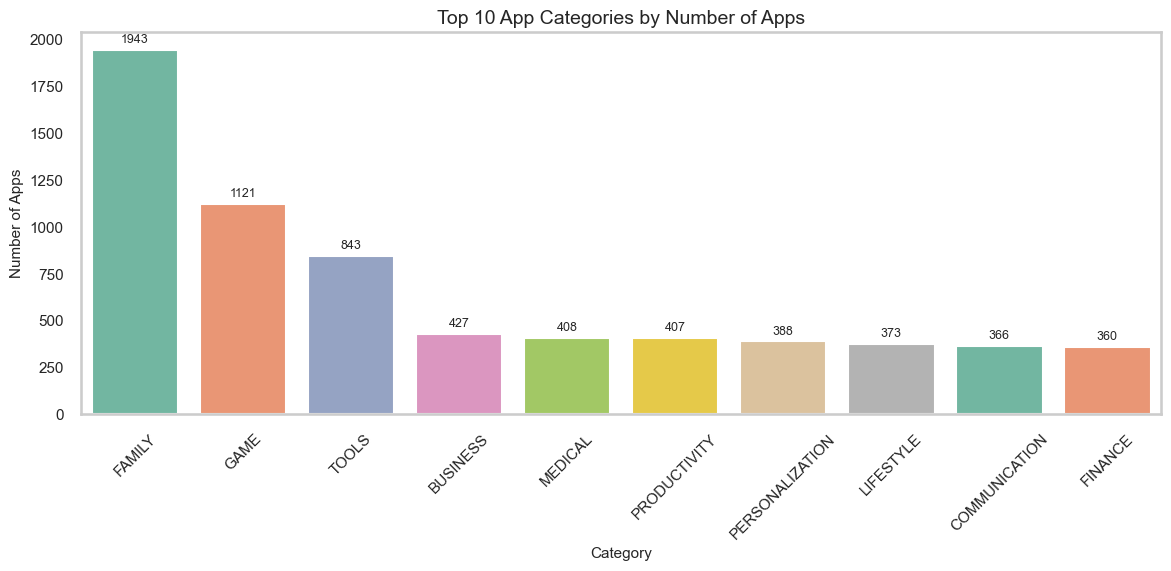

In [302]:
# plt the graph 
plt.figure(figsize=(12, 6))

top_categories = data['category'].value_counts().head(10)
ax = sns.barplot(x=top_categories.index,
            y=top_categories.values, 
            palette='Set2')
# label on bars 
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

# grid
plt.grid(False)

# label and title     
plt.title("Top 10 App Categories by Number of Apps", fontsize=14)
plt.xlabel("Category", fontsize=11)
plt.ylabel("Number of Apps", fontsize=11)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

```4.3: Free vs Paid Apps```

In [303]:
data['type'].value_counts()

type
Free    9592
Paid     765
Name: count, dtype: int64

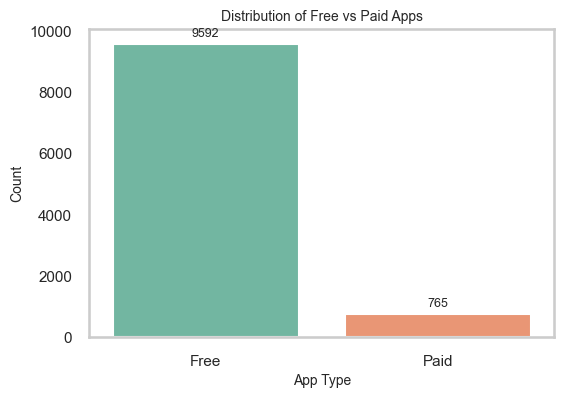

In [304]:
# plot the graph
plt.figure(figsize=(6,4))
ax = sns.countplot(data=data, x='type', palette='Set2')

# label on bar
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

# grid
plt.grid(False)
    
plt.title('Distribution of Free vs Paid Apps',fontsize = 10)
plt.xlabel('App Type',fontsize = 10)
plt.ylabel('Count',fontsize = 10)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()


```4.4: Price Distribution for Paid Apps```


In [305]:
data[['price','type']].head(5)

,price,type
0,0.0,Free
1,0.0,Free
2,0.0,Free
3,0.0,Free
4,0.0,Free


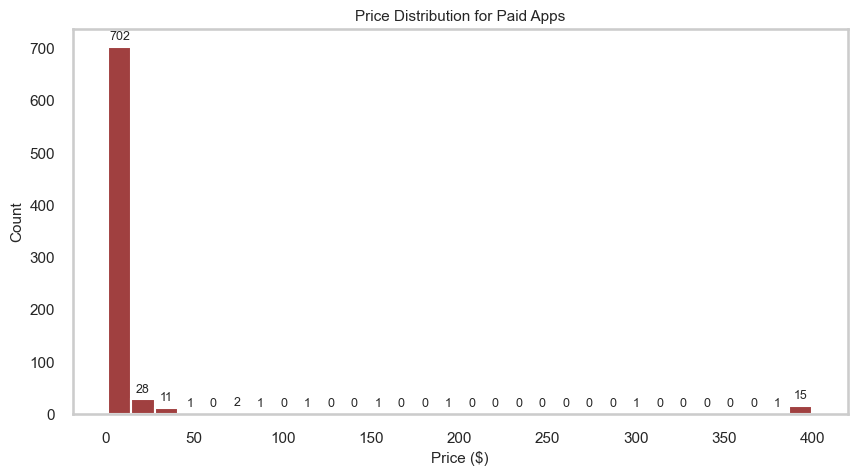

In [314]:
paid_apps = data[data['type'] == 'Paid']

#plot graph
plt.figure(figsize=(10,5))
ax = sns.histplot(paid_apps['price'], bins=30, color='maroon')

# label on bar
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

# grid
plt.grid(False)

# label and title 
plt.title('Price Distribution for Paid Apps', fontsize = 11)
plt.xlabel('Price ($)' , fontsize = 11)
plt.ylabel('Count' , fontsize = 11)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

```4.5:Distribution of Content Ratings```

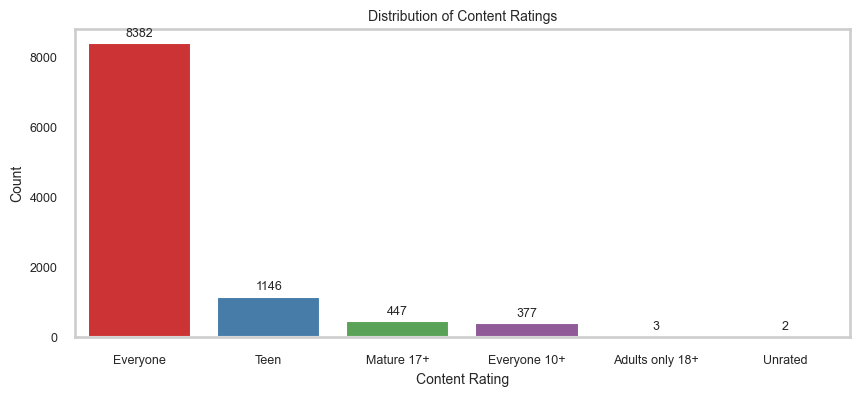

In [334]:
content_ratings = data['content_rating'].value_counts()

# plot the graph
plt.figure(figsize=(10,4))
ax = sns.barplot(x=content_ratings.index, y=content_ratings.values,
palette='Set1')

# apply label on bars 
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

# grid
plt.grid(False)
    
# label and title 
plt.title('Distribution of Content Ratings', fontsize = 10)
plt.xlabel('Content Rating', fontsize = 10)
plt.ylabel('Count', fontsize = 10)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.show()
plt.show()

```4.6: Top Genres by Install Count```

In [337]:
top_genres_installs = data.groupby('genres')['installs'].sum().sort_values(ascending=False).head(10)
top_genres_installs

genres
Communication              2.415228e+10
Social                     1.251387e+10
Productivity               1.246309e+10
Tools                      1.144277e+10
Photography                9.721248e+09
Arcade                     9.717129e+09
Casual                     8.662831e+09
Action                     8.336039e+09
Travel & Local             6.361787e+09
Video Players & Editors    6.207003e+09
Name: installs, dtype: float64

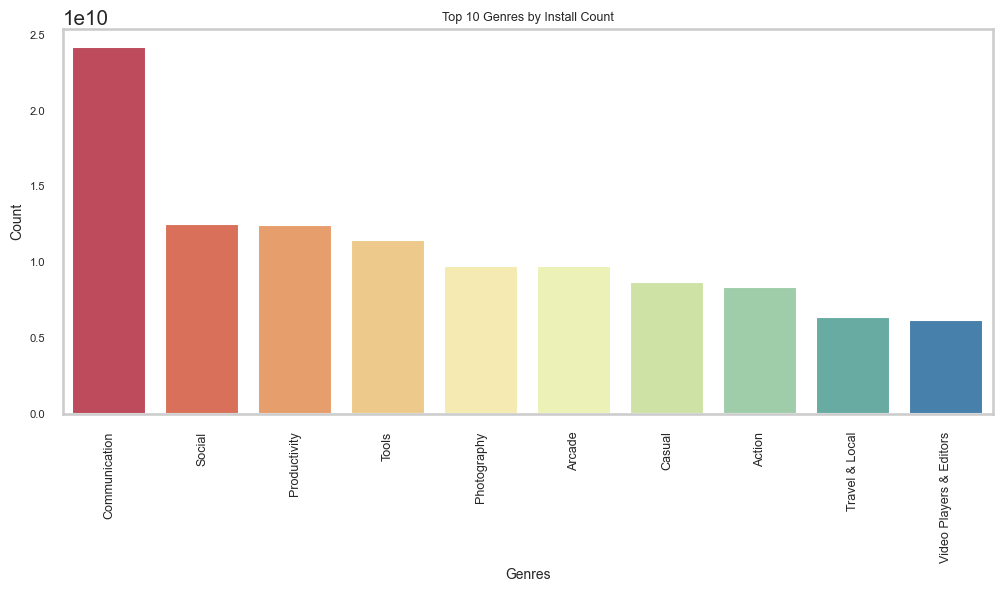

In [344]:
# plot graph 
plt.figure(figsize=(12,5))
sns.barplot(x=top_genres_installs.index,y=top_genres_installs.values, palette='Spectral')

# grid
plt.grid(False)

# label and title 
plt.title('Top 10 Genres by Install Count', fontsize = 9 )
plt.xlabel("Genres", fontsize = 10)
plt.ylabel("Count", fontsize = 10)

plt.xticks(rotation=90, fontsize = 9)
plt.yticks(fontsize = 8)
plt.show()

### Feature Encoding 

In [347]:
# call dataset 
data.head(5)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [351]:
# Encode categorical columns
le = LabelEncoder()
data['category'] = le.fit_transform(data['category'])
data['type'] = le.fit_transform(data['type'])
data['content_rating'] = le.fit_transform(data['content_rating'])
data['genres'] = le.fit_transform(data['genres'])

In [352]:
# see data set again after encode 
data.head(5)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,0,4.1,159,19.0,10000.0,0,0.0,1,9,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,0,3.9,967,14.0,500000.0,0,0.0,1,12,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0,4.7,87510,8.7,5000000.0,0,0.0,1,9,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,0,4.5,215644,25.0,50000000.0,0,0.0,4,9,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,0,4.3,967,2.8,100000.0,0,0.0,1,11,"June 20, 2018",1.1,4.4 and up


### Feature Selection

In [353]:
# select feature for x and y 
x = data[['category', 'rating', 'reviews', 'size', 'installs', 'type', 'price', 'content_rating', 'genres']]
y = data['rating']

In [354]:
x

,category,rating,reviews,size,installs,type,price,content_rating,genres
0,0,4.1,159,19.0,10000.0,0,0.0,1,9
1,0,3.9,967,14.0,500000.0,0,0.0,1,12
2,0,4.7,87510,8.7,5000000.0,0,0.0,1,9
3,0,4.5,215644,25.0,50000000.0,0,0.0,4,9
4,0,4.3,967,2.8,100000.0,0,0.0,1,11
...,...,...,...,...,...,...,...,...,...
10836,11,4.5,38,53.0,5000.0,0,0.0,1,39
10837,11,5.0,4,3.6,100.0,0,0.0,1,39
10838,20,4.3,3,9.5,1000.0,0,0.0,1,71
10839,3,4.5,114,NaN,1000.0,0,0.0,3,19


###  Split the data

In [357]:
# split the data in to  x and y 
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size=0.3, random_state=42)

### Model Apply 

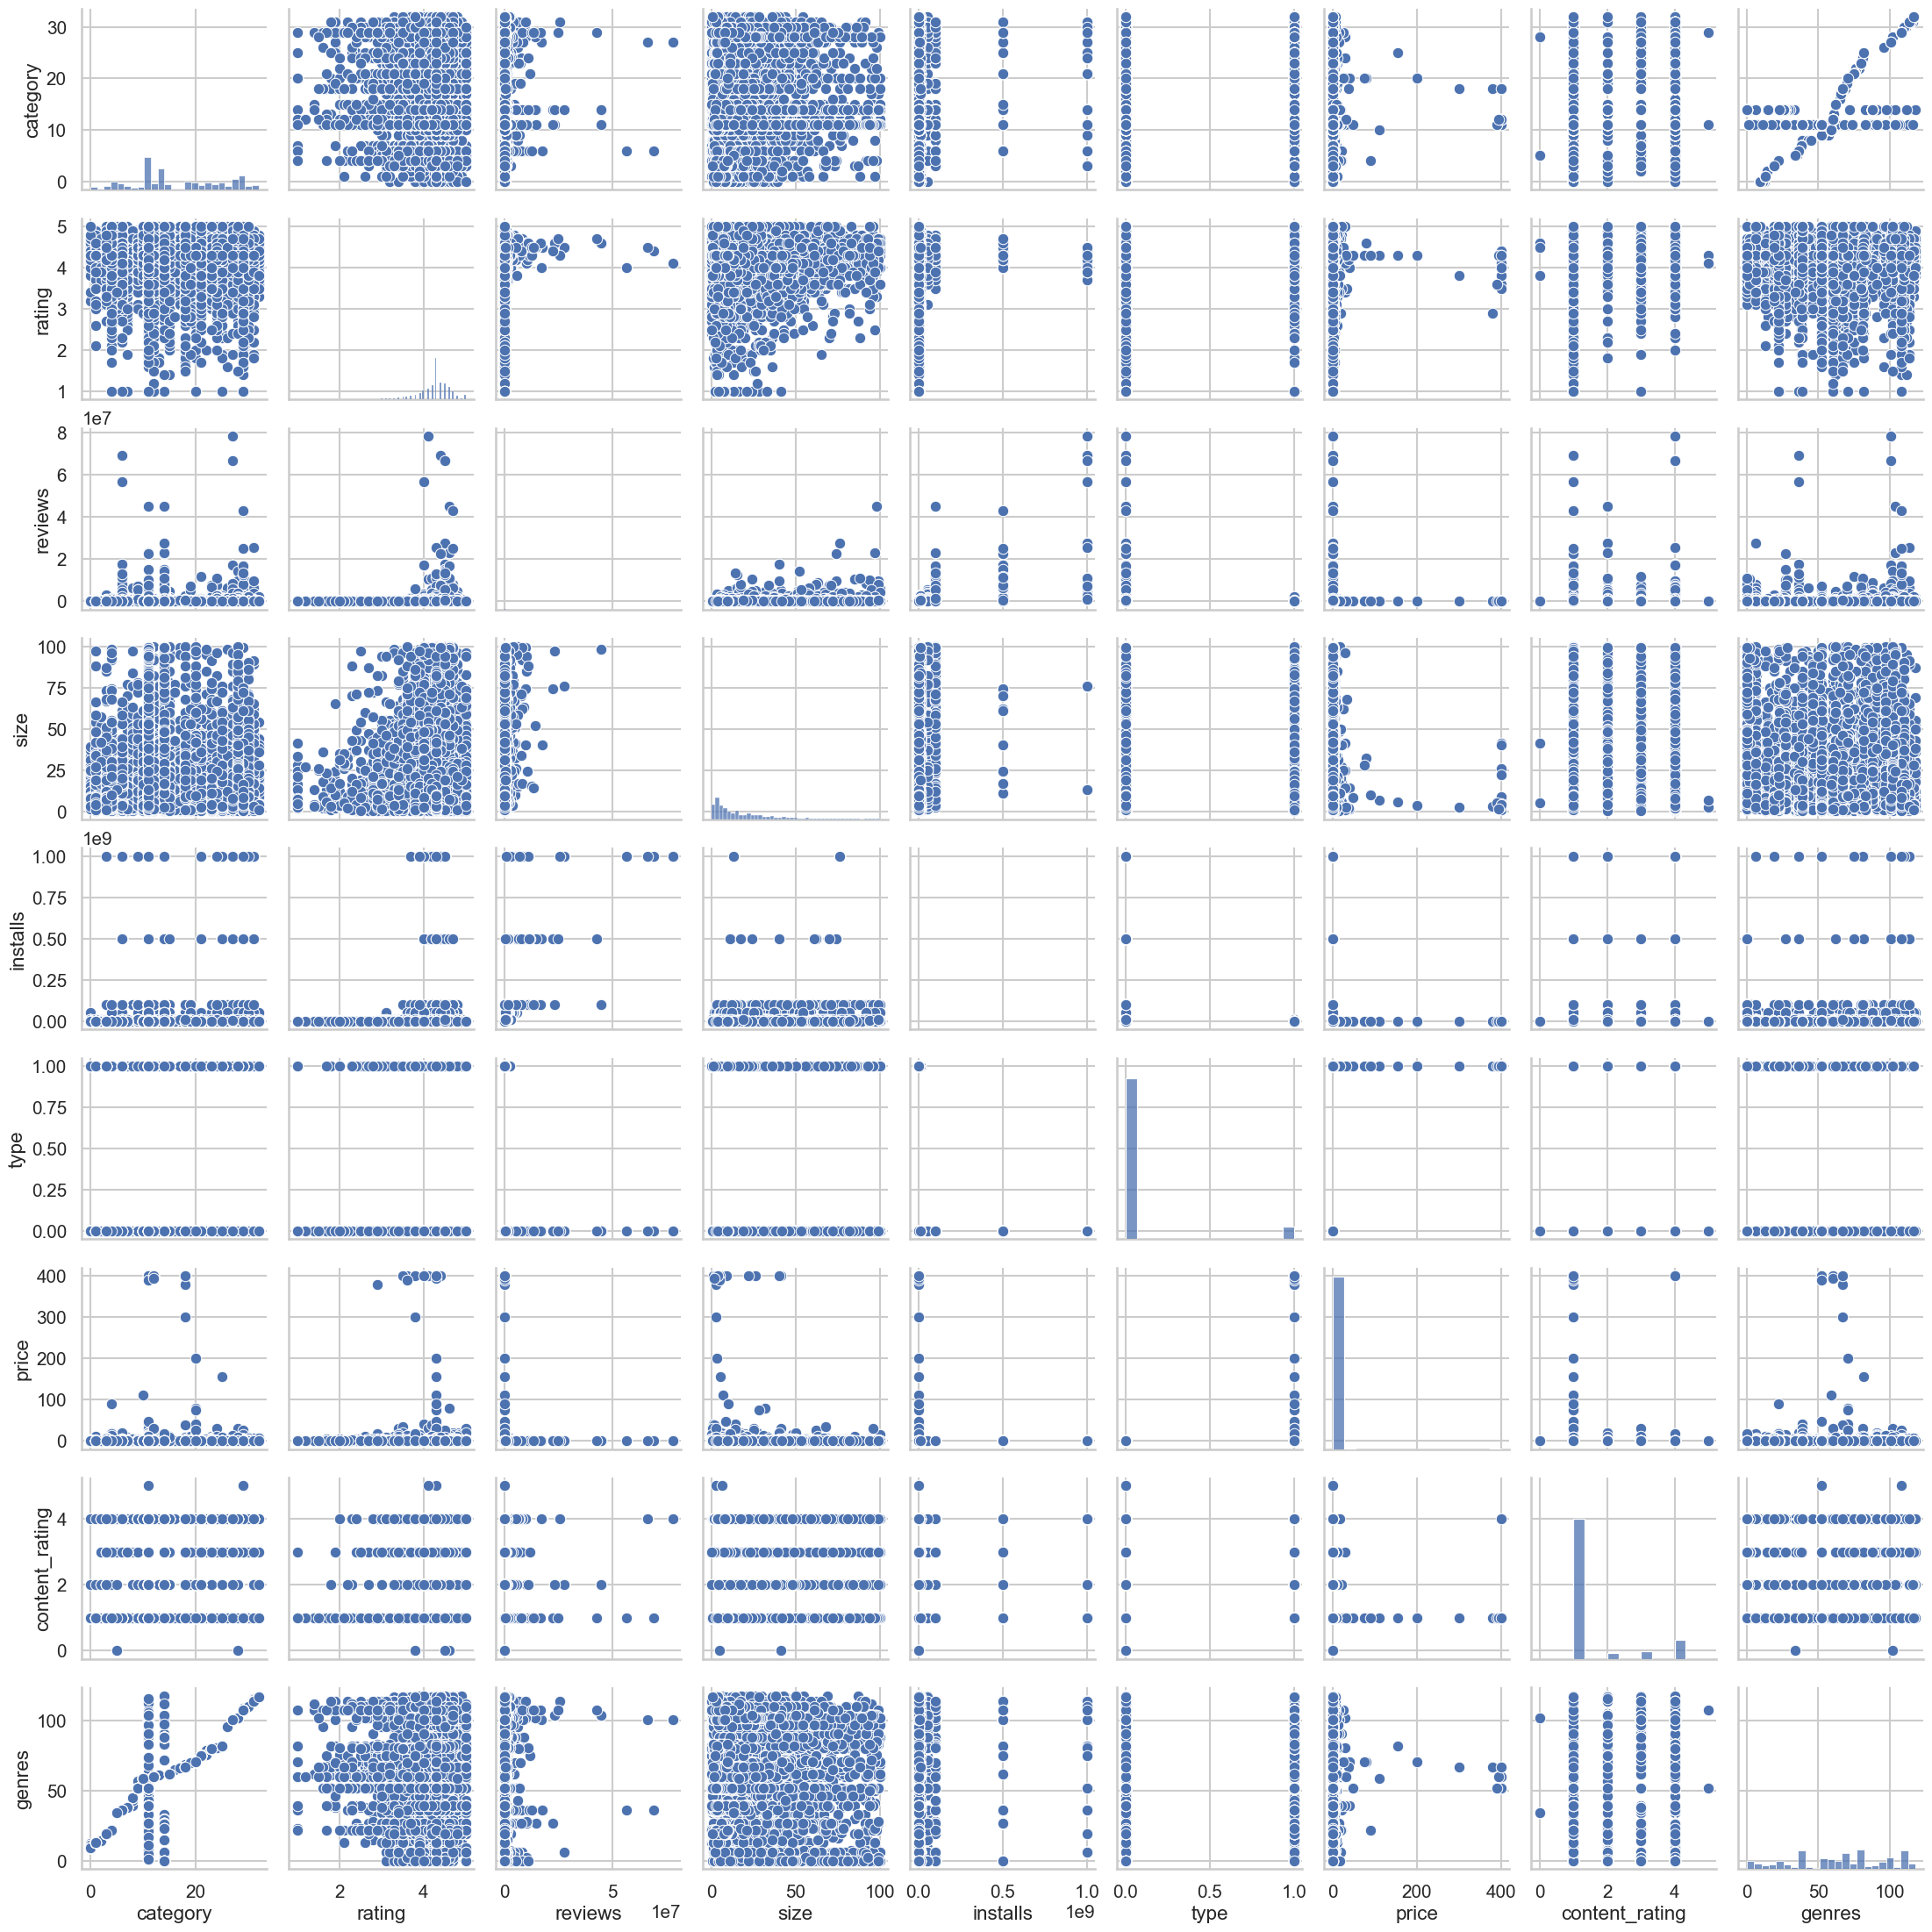

In [369]:
# see the behaviour of the dataset
sns.pairplot(data)
plt.show()

### Model Train 

In [359]:
# Train the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf.score(X_test, y_test)*100 , rf.score(X_train, y_train)*100

(99.98872496229161, 99.99961134370157)

In [360]:
# Predictions
y_pred = rf.predict(X_test)

### Evaluate the model

In [361]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 2.613384813384836e-05
R-squared: 0.9998872496229162


In [362]:
# Display actual vs predicted values for the first 10 samples
comparison = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': y_pred.flatten()})
comparison.head(10)

,Actual,Predicted
0,4.3,4.3
1,3.4,3.4
2,4.1,4.1
3,4.3,4.3
4,4.7,4.7
5,4.2,4.2
6,3.7,3.7
7,4.4,4.4
8,4.7,4.7
9,4.6,4.6


### Visualize Model Performance

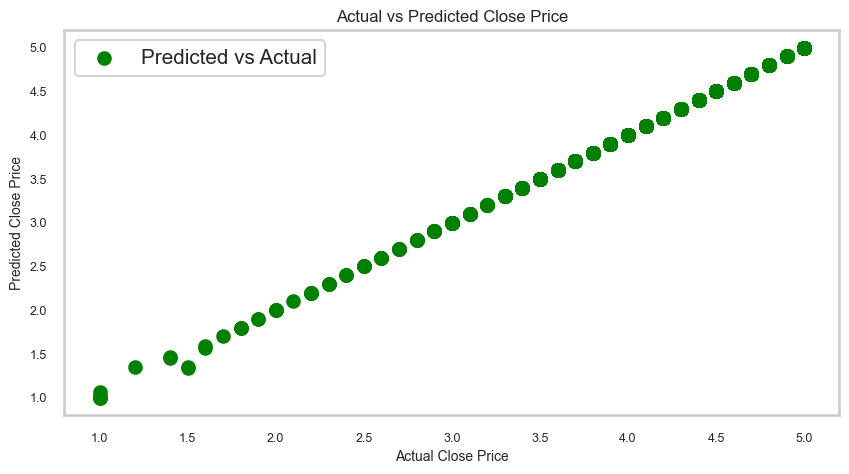

In [367]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='green', label='Predicted vs Actual')

# grid
plt.grid(False)

# label and title 
plt.xlabel('Actual Close Price',fontsize = 10)
plt.ylabel('Predicted Close Price', fontsize = 10)
plt.title('Actual vs Predicted Close Price', fontsize = 12)

plt.xticks(fontsize = 9)
plt.yticks(fontsize = 9)

plt.legend()
plt.show()

### Save the Model

In [368]:
import pickle
with open('Google_Playstore_Predictor.pkl', 'wb') as file:
    pickle.dump(rf, file)

print("Model Saved Successfully")

Model Saved Successfully


### ```Conclusion``` Google Play Store App Rating Prediction
* Performed end-to-end data analysis on Google Play Store apps, including installs, reviews, app size, price, category, content rating, and app type, using data fetched from PostgreSQL.

* Applied data cleaning, preprocessing, feature encoding, and exploratory data analysis (EDA) to prepare the dataset for modeling.

* Built and evaluated multiple regression models, with Random Forest Regressor selected as the best-performing model.

* The final model achieved very high accuracy with:

* R² Score: 0.9998

* Mean Squared Error (MSE): 3.58 × 10⁻⁵

* Model performance was validated using evaluation metrics and visualizations, confirming strong predictive capability for app ratings.

* The trained model was successfully saved for future deployment or reuse, and further improvements can be explored using Ridge Regression, SVR, or hyperparameter tuning.